# Projeto IA - Unidade 1
## Dia 1 e 2: Análise Exploratória e Pré-Processamento

Este notebook cobre a carga inicial dos dados, a análise exploratória (EDA) e as rotinas de pré-processamento.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, fetch_california_housing

# Configurações de visualização para deixar os gráficos mais elegantes
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### 1. Carregando os Datasets (Dia 1)
- **Classificação:** Breast Cancer Wisconsin
- **Regressão:** California Housing

In [2]:
# Carregando dataset de Classificação
cancer_data = load_breast_cancer()
df_classificacao = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
df_classificacao['target'] = cancer_data.target # Adicionando a coluna alvo

# Carregando dataset de Regressão
housing_data = fetch_california_housing()
df_regressao = pd.DataFrame(housing_data.data, columns=housing_data.feature_names)
df_regressao['MedHouseVal'] = housing_data.target # Adicionando a coluna alvo

print("Datasets carregados com sucesso!")

Datasets carregados com sucesso!


### 2. Inspeção Inicial: Formato e Valores Nulos (Dia 1)

In [3]:
print(f"Dataset de Classificação (Câncer): {df_classificacao.shape[0]} amostras, {df_classificacao.shape[1]} colunas")
display(df_classificacao.head(3))
print("Valores nulos:", df_classificacao.isnull().sum().sum())

print(f"\nDataset de Regressão (Imóveis): {df_regressao.shape[0]} amostras, {df_regressao.shape[1]} colunas")
display(df_regressao.head(3))
print("Valores nulos:", df_regressao.isnull().sum().sum())

Dataset de Classificação (Câncer): 569 amostras, 31 colunas


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0


Valores nulos: 0

Dataset de Regressão (Imóveis): 20640 amostras, 9 colunas


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521


Valores nulos: 0


---
## 📊 Dia 2: Análise Exploratória (EDA)

### EDA 1. Estatísticas Descritivas
Analisando a média, desvio padrão e quartis numéricos de ambos os datasets.

In [4]:
print("--- Estatísticas Classificação ---")
display(df_classificacao.describe())

print("\n--- Estatísticas Regressão ---")
display(df_regressao.describe())

--- Estatísticas Classificação ---


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000



--- Estatísticas Regressão ---


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### EDA 2. Desbalanceamento de Classes (Dataset de Classificação)
Verificando se há mais casos benignos ou malignos no dataset de Câncer de Mama.

C:\Users\Jacson\AppData\Local\Temp\ipykernel_15432\3008123675.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_classificacao, x='target', palette='Set2')


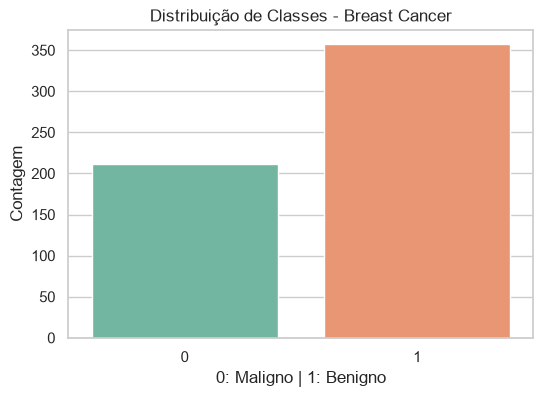

Proporção real:
 target
1    62.741652
0    37.258348
Name: proportion, dtype: float64


In [5]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df_classificacao, x='target', palette='Set2')
plt.title('Distribuição de Classes - Breast Cancer')
plt.xlabel('0: Maligno | 1: Benigno')
plt.ylabel('Contagem')
plt.show()

print("Proporção real:\n", df_classificacao['target'].value_counts(normalize=True) * 100)

### EDA 3. Histogramas e Boxplots (Regressão)
Analisando a distribuição do Alvo (Preço da Casa) e detectando outliers.

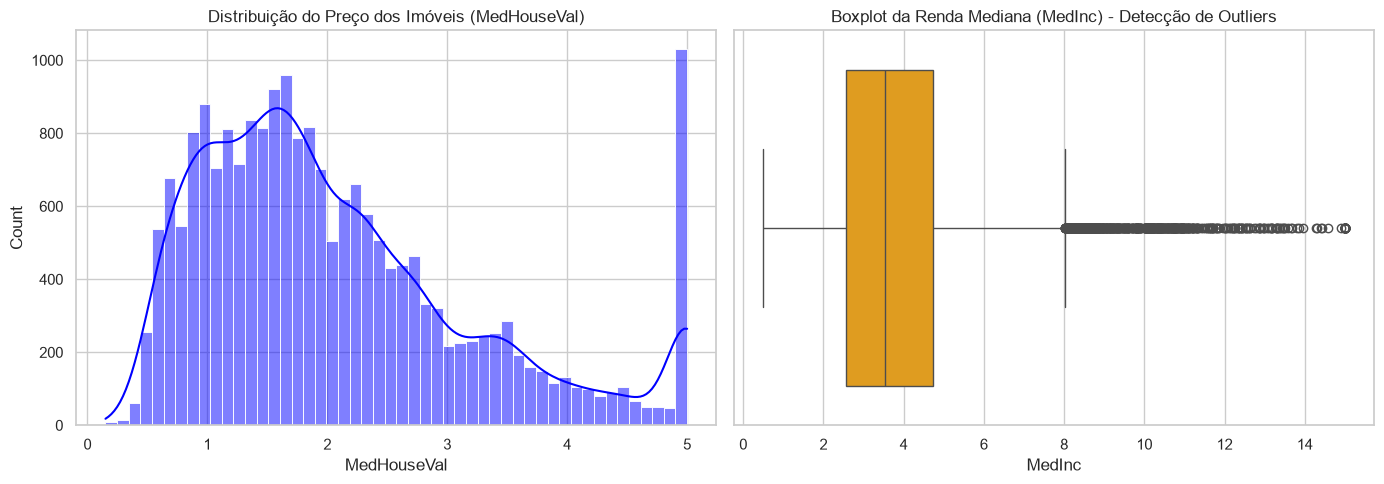

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma para ver a distribuição de preços
sns.histplot(df_regressao['MedHouseVal'], bins=50, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribuição do Preço dos Imóveis (MedHouseVal)')

# Boxplot da Renda Mediana para identificar outliers
sns.boxplot(x=df_regressao['MedInc'], ax=axes[1], color='orange')
axes[1].set_title('Boxplot da Renda Mediana (MedInc) - Detecção de Outliers')

plt.tight_layout()
plt.show()

---
## ⚙️ Dia 2: Pré-Processamento
Nesta etapa, isolamos o alvo (y) das variáveis (X), dividimos os dados em conjuntos de Treino e Teste e aplicamos a padronização (StandardScaler).

### 1. Pré-Processamento: Classificação (Breast Cancer)

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separando Features (X) e Alvo (y)
X_clf = df_classificacao.drop(columns=['target'])
y_clf = df_classificacao['target']

# Divisão Treino/Teste (80/20) 
# Usamos stratify=y_clf para garantir que a proporção de tumores benignos/malignos seja igual no treino e no teste
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# Padronização (O scaler 'aprende' a escala apenas no Treino, e aplica essa regra no Treino e no Teste)
scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

print("Classificação - Dimensões do Treino (X_train):", X_train_clf_scaled.shape)
print("Classificação - Dimensões do Teste (X_test):", X_test_clf_scaled.shape)

Classificação - Dimensões do Treino (X_train): (455, 30)
Classificação - Dimensões do Teste (X_test): (114, 30)


### 2. Pré-Processamento: Regressão (California Housing)

In [8]:
# Separando Features (X) e Alvo (y)
X_reg = df_regressao.drop(columns=['MedHouseVal'])
y_reg = df_regressao['MedHouseVal']

# Divisão Treino/Teste (80/20) 
# Aqui NÃO usamos stratify porque o alvo (preço) é um número contínuo, e não uma classe categórica.
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Padronização
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

print("Regressão - Dimensões do Treino (X_train):", X_train_reg_scaled.shape)
print("Regressão - Dimensões do Teste (X_test):", X_test_reg_scaled.shape)

Regressão - Dimensões do Treino (X_train): (16512, 8)
Regressão - Dimensões do Teste (X_test): (4128, 8)


### ✅ Conclusão do Dia 2
Os dados estão limpos, inspecionados, separados e matematicamente padronizados. 
Estão 100% prontos para serem inseridos nos algoritmos de Machine Learning.